# LABOR-3: R&S FPC1500 Spektrum-Analyzer (SCPI)

## Ziele der Übung

## A) Kennenlernen des Geräts  

Ziel dieser Übung ist das Kennenlernen der Messtechnik mit einem professionellen Spektrum-Analyzer (**Rohde & Schwarz FPC1500**), der zusätzlich auch eine **Vector Network Analyzer (VNA)**-Funktion bietet.

Da im Labor nur ein Gerät verfügbar ist und die Messungen nacheinander stattfinden müssen, ist dieses Notebook so aufgebaut, dass zunächst mit einer aufgezeichneten Messung gearbeitet werden kann. Diese Funktion wird mit der Variablen **`REPLAY=True`** aktiviert.

Die Kernaufgabe besteht darin, das Spektrum eines VFO-Signalgenerators zu untersuchen und mit zwei Markern einen Frequenzbereich auszuwählen. Innerhalb dieses Bereichs wird die **Channel-Power** (Gesamtleistung in der gewählten Bandbreite) bestimmt und im Spektralplot angezeigt.

Diese Programmieraufgabe kann vollständig mit Replay-Daten bearbeitet werden. Eine reale Messung kann später mit **`REPLAY=False`** durchgeführt werden. Die dabei aufgenommenen Daten werden gespeichert und können danach erneut offline genutzt werden.

Der FPC1500 wird über **Ethernet** mit dem PC verbunden. Im Praktikum wird dazu ein USB/Ethernet-Adapter verwendet, dessen IP-Konfiguration zur Analyzer-IP (**`192.168.1.10`**) passen muss. Die Datenübertragung vom Gerät zum PC erfolgt über das **SCPI-Protokoll**.

Damit soll das Gerät auch für weitere Übungen ausserhalb der Laborzeiten (asynchrone Laborübung) einfach nutzbar sein.

**Voraussetzung:** FPC1500 ist per Netzwerk erreichbar (IP und Port unten konfigurierbar).

### B) Selbstständige Messung eines Signal in einem gültigen CB (Citizen-Band) Funkkanal, diese Frequenzen bitte recherchieren!  


## Ethernet/USB-Adapter
![ETH-USB](media/ETH-USB.jpg)

Der Analyzer FPC1500 ist mit einer statischen IP Adresse 192.168.1.10 konfiguriert, damit wird vermieden , dass sich dessen Adresse bei Verwendung von DHCP im Intranet immer wieder ändert.  
Die IP Adresse für den Adapter muss unter den **Netzwerkeinstellungen** auf eine gültige und eindeutige Netzwerkadresse 192.168.1.X / 255.255.255.0 gesetzt werden.

### Konfiguration: IP-Adresse und Port

IP und Port des FPC1500 einstellen (Gerät ist normalerweise voreingestellt auf 192.168.1.10). Standard-Port für SCPI ist oft **5555**.

![FPC1500](media/fpc1500-SA1.jpg)

## Kurzinfo Bedienfeld:
![Buttons](media/fpc1500-buttons.jpg)


### FPC1500 – Bedienung (einfach erklärt)
- **Mode:**  
  Hier wählst du, *was* das Gerät sein soll:  
  **Spectrum Analyzer** (Spektrum messen) oder **Network Analyzer** (z. B. S11/S21 messen).
- **Setup:**  
  Grundeinstellungen des Geräts, z. B. Netzwerk (IP-Adresse wie `192.168.1.10`).
- **Meas:**  
  Auswahl der Messart innerhalb des aktuellen Modes.
- **Freq / Span:**  
  Hier legst du den betrachteten Frequenzbereich fest:  
  entweder über **Start/Stop** oder über **Center/Span**.
- **BW:**  
  - **RBW (Resolution Bandwidth):** bestimmt, wie fein das Spektrum aufgelöst wird.  
    Kleinere RBW = feinere Details, aber meist langsamere Messung.  
  - **VBW (Video Bandwidth):** glättet die Anzeige.  
    Kleinere VBW = ruhigeres Display, ohne die eigentliche Messphysik stark zu ändern.
- **Ampt:**  
  Einstellung des **Reference Level** (oberer Pegelrand der Anzeige in dBm).
- **Mkr / Mkr >:**  
  Marker einblenden und Marker-Funktionen nutzen, z. B.:  
  **Peak Search** (größtes Signal finden), **Marker to Center** usw.

## Signalgenerator 10kHz - 220MHz
![VFO](media/VFO-1.jpg)


### Bedienung des Signalgenerators
- **Step:**  
  Durch wiederholtes Drücken wird die Schrittweite der Frequenzeinstellung ausgewählt.  
  Die aktuell gewählte Schrittweite wird im Display angezeigt (`1 Hz` bis `10 MHz`).
- **Drehknopf links/rechts:**  
  Erhöht bzw. verringert die Frequenz um die aktuell eingestellte Schrittweite.
- **Drehknopf drücken:**  
  Wechselt zum nächsten Frequenzband (Amateurfunkbänder).
- **`TX/RX` kurz drücken:**  
  Umschalten zwischen `TX` und `RX`.
- **`TX/RX` lang drücken:**  
  Wenn `RX` aktiv ist, wird eine Standard-ZF für die Frequenzablage gesetzt.  
  Die eingestellte Frequenz wird dabei um diese ZF verschoben (typischerweise erhöht).
> **Hinweis:**  
> Bei `Step = 1 kHz` verändert eine Rastung des Drehknopfs die Frequenz um `1 kHz`.
> **Beispiel (RX mit ZF-Ablage):**  
> Eingestellte Frequenz: `433.920 MHz`  
> Standard-ZF: `10.700 MHz`  
> Abgelegte Frequenz: `444.620 MHz`


In [7]:
import json
import socket
from pathlib import Path
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from matplotlib.widgets import Slider

try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

# FPC1500: konfigurierbare Verbindung
FPC_IP = "192.168.1.10"
FPC_PORT = 5555
SOCKET_TIMEOUT = 5.0
SCREENSHOT_TIMEOUT = 10.0   # HCOP und Auslesen können deutlich länger als 5 s dauern
TRACE_READ_MAX_BYTES = 256 * 1024

# Offline-Workflow: bei REPLAY=True werden Messdaten aus JSON geladen
REPLAY = True
REPLAY_FILE = Path("recordings") / "fpc1500_sa_replay.json"

# Screenshots lokal speichern (Laborprotokoll, persistent)
SCREENSHOT_DIR = Path("screenshots")

def scpi_query(host: str, port: int, cmd: str, max_bytes: int = 4096) -> str:
    """SCPI-Befehl senden, Antwort lesen (bis Newline oder max_bytes)."""
    cmd = cmd.strip() + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SOCKET_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < max_bytes:
            chunk = s.recv(8192)
            if not chunk:
                break
            buf += chunk
            if b"\n" in buf:
                break
        return buf.decode("utf-8", errors="replace").strip()
    finally:
        s.close()

def get_trace_data(host: str, port: int):
    """Frequenzachse (Hz), Trace-Werte (dBm) und RBW (Hz) vom FPC lesen.
    Returns (freqs, amps, rbw_hz) oder None.
    """
    try:
        trace_s = scpi_query(host, port, "TRAC:DATA? TRACE1", max_bytes=TRACE_READ_MAX_BYTES)
    except Exception:
        return None
    amps = []
    for part in trace_s.replace(",", " ").split():
        try:
            amps.append(float(part))
        except ValueError:
            continue
    if not amps:
        return None

    try:
        star_s = scpi_query(host, port, "FREQ:STAR?", max_bytes=256)
        stop_s = scpi_query(host, port, "FREQ:STOP?", max_bytes=256)
        freq_start = float(star_s.strip())
        freq_stop = float(stop_s.strip())
    except Exception:
        try:
            cent_s = scpi_query(host, port, "FREQ:CENT?", max_bytes=256)
            span_s = scpi_query(host, port, "FREQ:SPAN?", max_bytes=256)
            cent = float(cent_s.strip())
            span = float(span_s.strip())
            freq_start = cent - span / 2
            freq_stop = cent + span / 2
        except Exception:
            return None

    rbw_hz = None
    for rbw_cmd in ["BAND:RES?", "BANDwidth:RESolution?"]:
        try:
            rbw_hz = float(scpi_query(host, port, rbw_cmd, max_bytes=256).strip())
            break
        except Exception:
            continue

    n = len(amps)
    freqs = [freq_start + (freq_stop - freq_start) * i / max(1, n - 1) for i in range(n)]
    return (freqs, amps, rbw_hz)

def screenshot_save(host: str, port: int, filename: str = "screen.png") -> str | None:
    """Hardcopy auf dem Gerät auslösen und in MMEM speichern. Returns None bei Erfolg, sonst Fehlermeldung."""
    commands = ["HCOP:DEV:LANG PNG", "HCOP:DEST 'MMEM'", f"MMEM:NAME '{filename}'", "HCOP:IMM"]
    cmd = "\n".join(commands) + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < 4096:
            try:
                chunk = s.recv(1024)
                if not chunk:
                    break
                buf += chunk
                if b"\n" in buf:
                    break
            except socket.timeout:
                break
        reply = buf.decode("utf-8", errors="replace").strip()
        if reply and "error" in reply.lower():
            return reply
        return None
    except Exception as e:
        return str(e)
    finally:
        s.close()


def save_replay_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_replay_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Replay-Datei nicht gefunden: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


def screenshot_read(host: str, port: int, filename: str) -> bytes | None:
    """Datei vom Gerät (MMEM) lesen. MMEM:DATA? Antwort im IEEE 488.2-Blockformat. Returns PNG-Bytes oder None."""
    cmd = f"MMEM:DATA? '{filename}'\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while b"#" not in buf and len(buf) < 1024:
            chunk = s.recv(256)
            if not chunk:
                return None
            buf += chunk
        if b"#" not in buf:
            return None
        start = buf.index(b"#")
        buf = buf[start:]
        if len(buf) < 2:
            buf += s.recv(2 - len(buf))
        n_digits = int(chr(buf[1]))
        if n_digits < 1 or n_digits > 9:
            return None
        while len(buf) < 2 + n_digits:
            buf += s.recv(2 + n_digits - len(buf))
        data_len = int(buf[2 : 2 + n_digits].decode())
        buf = buf[2 + n_digits :]
        while len(buf) < data_len:
            chunk = s.recv(min(65536, data_len - len(buf)))
            if not chunk:
                break
            buf += chunk
        return buf[:data_len] if len(buf) >= data_len else None
    except Exception:
        return None
    finally:
        s.close()

print("Konfiguration:", FPC_IP, "Port", FPC_PORT)
print(f"REPLAY={REPLAY}, Datei={REPLAY_FILE}")

Konfiguration: 192.168.1.10 Port 5555
REPLAY=True, Datei=recordings\fpc1500_sa_replay.json


### Verbindung testen (*IDN?)

In [8]:
if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    reply = replay.get("idn", "REPLAY")
    print("Gerät (Replay):", reply)
else:
    reply = scpi_query(FPC_IP, FPC_PORT, "*IDN?")
    print("Gerät:", reply if reply else "Keine Antwort (IP/Port prüfen, Gerät eingeschaltet?).")

Gerät (Replay): Rohde&Schwarz,FPC1500,1328.6660K03/206021,V1.90


### Spektrum auslesen und plotten

Trace-Daten (TRACE1) und Frequenzbereich werden per SCPI gelesen und als Betragsspektrum dargestellt.

P_spec (Marker-Band) [dBm]: 7.921732946983543


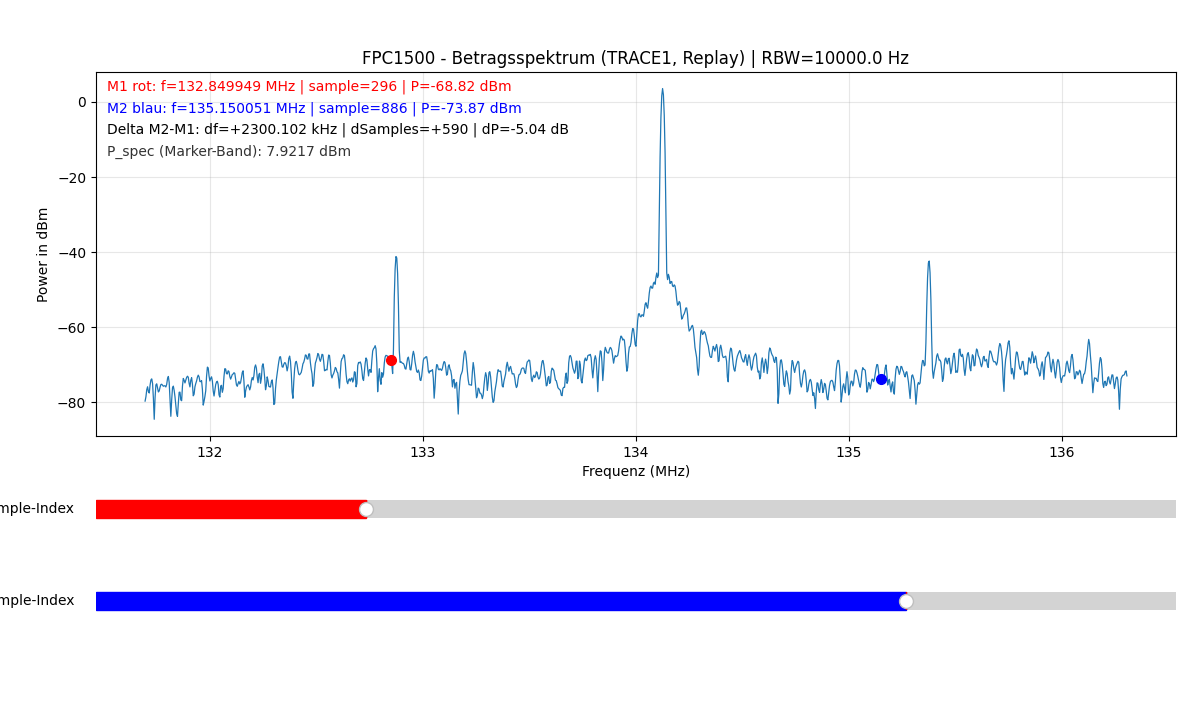

1183 Punkte, Frequenzbereich 131.6960 ... 136.3040 MHz
RBW: 10000.0 Hz


In [14]:
if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    freqs = replay.get("freqs_hz", [])
    amps = replay.get("amps", [])
    rbw_hz = replay.get("rbw_hz", None)
else:
    result = get_trace_data(FPC_IP, FPC_PORT)
    if result is None:
        print("Trace-Daten konnten nicht gelesen werden.")
        freqs, amps, rbw_hz = [], [], None
    else:
        freqs, amps, rbw_hz = result
        save_replay_json(
            REPLAY_FILE,
            {
                "meta": {"type": "fpc1500_sa", "version": 2},
                "idn": reply,
                "freqs_hz": list(freqs),
                "amps": list(amps),
                "rbw_hz": rbw_hz,
            },
        )
        print("Replay gespeichert:", REPLAY_FILE)

if not freqs or not amps:
    print("Keine gueltigen Spektrumsdaten vorhanden.")
else:
    freq_hz = np.asarray(freqs, dtype=float)
    # hier sind die Leistungswerte in dBm   <----- !!!!!!!
    p_dbm = np.asarray(amps, dtype=float)
    
    freq_mhz = freq_hz / 1e6
    n = p_dbm.size

    fig = plt.figure(figsize=(12.0, 7.2), constrained_layout=False)
    gs = fig.add_gridspec(3, 1, height_ratios=[1.0, 0.10, 0.10], hspace=0.38)
    ax = fig.add_subplot(gs[0, 0])
    ax_m1 = fig.add_subplot(gs[1, 0])
    ax_m2 = fig.add_subplot(gs[2, 0])
    fig.subplots_adjust(top=0.90, bottom=0.14, left=0.08, right=0.98)

    ax.plot(freq_mhz, p_dbm, color="C0", linewidth=0.9)
    ax.set_xlabel("Frequenz (MHz)")
    ax.set_ylabel("Power in dBm")
    rbw_txt = f" | RBW={rbw_hz:.1f} Hz" if (rbw_hz is not None) else " | RBW=n/a"
    title_mode = "Replay" if REPLAY else "Live"
    ax.set_title(f"FPC1500 - Betragsspektrum (TRACE1, {title_mode})" + rbw_txt)
    ax.grid(True, alpha=0.3)

    idx1_0 = int(round(0.25 * (n - 1)))
    idx2_0 = int(round(0.75 * (n - 1)))

    m1, = ax.plot([freq_mhz[idx1_0]], [p_dbm[idx1_0]], "o", color="red", ms=7)
    m2, = ax.plot([freq_mhz[idx2_0]], [p_dbm[idx2_0]], "o", color="blue", ms=7)

    info_m1 = ax.text(0.01, 0.98, "", color="red", fontsize=10, ha="left", va="top", transform=ax.transAxes)
    info_m2 = ax.text(0.01, 0.92, "", color="blue", fontsize=10, ha="left", va="top", transform=ax.transAxes)
    info_delta = ax.text(0.01, 0.86, "", color="black", fontsize=10, ha="left", va="top", transform=ax.transAxes)
    info_power = ax.text(0.01, 0.80, "", color="0.2", fontsize=10, ha="left", va="top", transform=ax.transAxes)

    # Platzhalter: spektrale Gesamtleistung [dBm] aus den Werten vom numpy-array "p_dbm" im Marker-Intervall (in update_markers berechnen)
 

    s1 = Slider(
        ax=ax_m1,
        label="Marker 1 (rot) - Sample-Index",
        valmin=0,
        valmax=n - 1,
        valinit=idx1_0,
        valstep=1,
        color="red",
    )
    s2 = Slider(
        ax=ax_m2,
        label="Marker 2 (blau) - Sample-Index",
        valmin=0,
        valmax=n - 1,
        valinit=idx2_0,
        valstep=1,
        color="blue",
    )
    ax_m1.set_facecolor("#f7f7f7")
    ax_m2.set_facecolor("#f7f7f7")

    def update_markers(_=None):
        global spectral_power_dbm
        i1 = int(s1.val)
        i2 = int(s2.val)

        m1.set_data([freq_mhz[i1]], [p_dbm[i1]])
        m2.set_data([freq_mhz[i2]], [p_dbm[i2]])

        df_hz = freq_hz[i2] - freq_hz[i1]
        df_khz = df_hz / 1000.0
        di = i2 - i1
        dp_db = p_dbm[i2] - p_dbm[i1]

        info_m1.set_text(
            f"M1 rot: f={freq_mhz[i1]:.6f} MHz | sample={i1} | P={p_dbm[i1]:.2f} dBm"
        )
        info_m2.set_text(
            f"M2 blau: f={freq_mhz[i2]:.6f} MHz | sample={i2} | P={p_dbm[i2]:.2f} dBm"
        )
        info_delta.set_text(
            f"Delta M2-M1: df={df_khz:+.3f} kHz | dSamples={di:+d} | dP={dp_db:+.2f} dB"
        )

        i_lo, i_hi = sorted((i1, i2))
        # Aufgabe: spectral_power_dbm = Gesamtleistung [dBm] zwischen Sample i_lo und i_hi (einschliesslich)
        # Da die Werte im Array logarithmisch sind, dürfen sie nicht einfach aufsummiert werden. Durch p_linear werden sie linearisiert, sodass 
        # sie summiert werden können. Damit der Werte im Endeffekt wieder in dBm ist, wird er nach der Summierung wieder logarithmiert.
        p_interval = p_dbm[i_lo : i_hi + 1]
        p_linear = 10**(p_interval / 10.0)
        spectral_power_dbm = 10 * np.log10(np.sum(p_linear))
        
        if spectral_power_dbm is None:
            info_power.set_text("P_spec (Marker-Band): None dBm — Platzhalter ersetzen")
        else:
            info_power.set_text(f"P_spec (Marker-Band): {spectral_power_dbm:.4f} dBm")

        fig.canvas.draw_idle()

    s1.on_changed(update_markers)
    s2.on_changed(update_markers)
    update_markers()

    print("P_spec (Marker-Band) [dBm]:", spectral_power_dbm)
    plt.show()

    print(f"{n} Punkte, Frequenzbereich {freq_mhz[0]:.4f} ... {freq_mhz[-1]:.4f} MHz")
    if rbw_hz is not None:
        print(f"RBW: {rbw_hz:.1f} Hz")

### Aufgabe: Spektrale Gesamtleistung zwischen den Markern

**Bestimme die gesamte spektrale Leistung innerhalb der durch die Marker festgelegten Bandbreite.**

Arbeite in der **Spektrum-Zelle** (mit Plot und Slidern):

1. Erkläre den beabsichtigten Rechengang als **Kommentar** (z. B. vor der Berechnung in `update_markers`).
2. Ersetze die **Platzhalter** `spectral_power_dbm = None`: einmal bei der **Initialisierung** und einmal **in `update_markers`** durch deine Berechnung aus `p_dbm` zwischen den **sortierten** Marker-Indizes `i_lo` … `i_hi` (einschließlich). Das Ergebnis ist ein Pegel in **dBm**.
3. Die **vierte Textzeile** im Plot (**P_spec**) soll dein Ergebnis anzeigen; **`print("P_spec (Marker-Band) [dBm]:", spectral_power_dbm)`** direkt vor `plt.show()` gibt den Wert nach dem ersten Update aus.

**Hinweis:** Solange der Platzhalter `None` steht, bleibt die Anzeige „None dBm“. Ersetze den Platzhalter durch das tatsächliche Rechenergebnis.



In [10]:
# Die Aufgabe ist in der Spektrum-Zelle umzusetzen (siehe Markdown-Zelle darueber).
pass

### Screenshot vom Gerät lesen und anzeigen

Hardcopy (PNG) auf dem FPC auslösen, dann Datei per MMEM:DATA? lesen und hier anzeigen.

### ACHTUNG:
Die Screenshot-Funktion dauert bis zu 10 Sekunden ! Solange wird auch die Zelle ausgeführt, was aus dem [*] -Symbol links der Zelle ersichtlich ist.


In [11]:
SCREENSHOT_FILENAME = "screen.png"

err = screenshot_save(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
if err:
    print("Screenshot (HCOP) Fehler:", err)
else:
    png_bytes = screenshot_read(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
    if png_bytes:
        SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        path = SCREENSHOT_DIR / f"fpc1500_{timestamp}.png"
        path.write_bytes(png_bytes)
        print("Gespeichert (Laborprotokoll):", path.resolve())
        display(Image(data=png_bytes))
    else:
        print("Screenshot auf Gerät gespeichert; Anzeige (MMEM:DATA?) nicht möglich oder nicht unterstützt.")

Screenshot (HCOP) Fehler: timed out


**Notebook exportieren (Laborprotokoll):** Über *File → Save and Export Notebook As…* bzw. **nbconvert** exportierbar als **HTML** (mit Ausgaben/Bildern), **PDF** oder **LaTeX**. Screenshots liegen dauerhaft im Ordner `screenshots/`.

In [12]:
# Platzhalter für eventuelle Kommentare